In [162]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [164]:
data = pd.read_csv('Final_data1.csv')

In [166]:
data.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,15
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,16
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,14
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,14
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,13


In [168]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 28 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   PATNO                                         1173 non-null   int64  
 1   BIRTHDT                                       1173 non-null   object 
 2   RACE                                          1173 non-null   object 
 3   SEX                                           1173 non-null   float64
 4   FamilyHistory                                 1173 non-null   float64
 5   Date of Parkinson's disease diagnosis         1173 non-null   object 
 6   Resting Tremor present at diagnosis?          1173 non-null   float64
 7   Rigidity present at diagnosis?                1173 non-null   float64
 8   Bradykinesia present at diagnosis?            1173 non-null   float64
 9   Postural instability present at dx?           1173 non-null   f

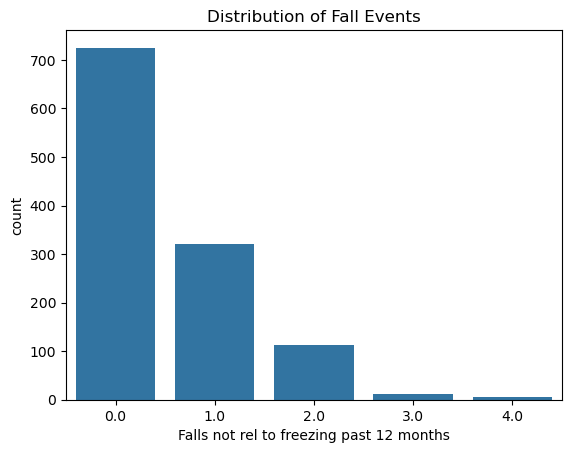

In [170]:
## Output label distribution
sns.countplot(x='Falls not rel to freezing past 12 months', data=data)
plt.title('Distribution of Fall Events')
plt.show()


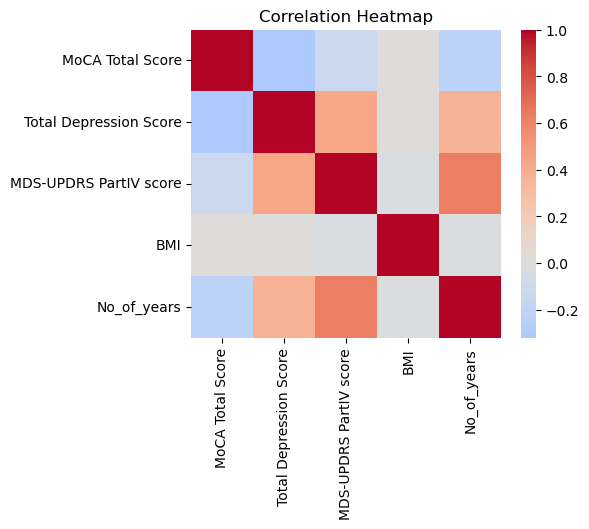

In [172]:
numeric_cols = ['MoCA Total Score','Total Depression Score','MDS-UPDRS PartIV score','BMI','No_of_years']
corr = data[numeric_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


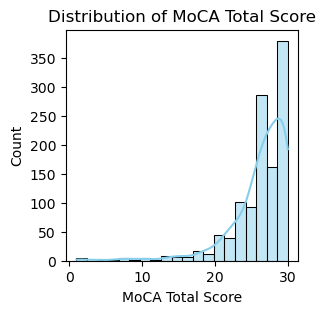

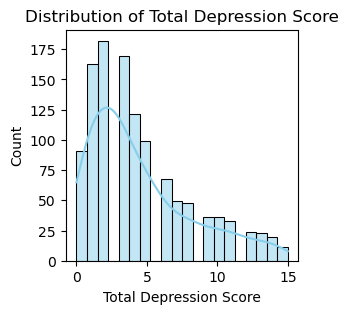

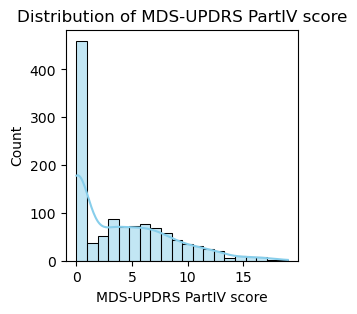

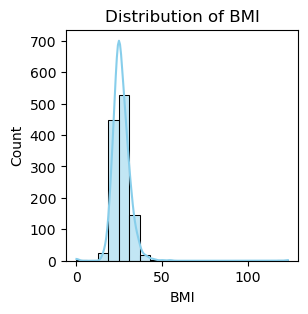

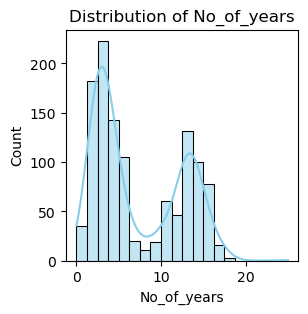

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(3,3))
    sns.histplot(data[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()


In [175]:
from scipy.stats import kruskal, f_oneway
import pandas as pd

target = 'Falls not rel to freezing past 12 months'

# Define numeric columns
num_non_normal = ['MoCA Total Score', 'Total Depression Score', 'MDS-UPDRS PartIV score', 'No_of_years']
num_normal = ['BMI']

results = []

# Kruskal–Wallis for non-normal numeric variables
for col in num_non_normal:
    groups = [data[col][data[target] == c].dropna() for c in data[target].unique()]
    if len(groups) > 1:
        stat, p = kruskal(*groups)
        results.append({'Variable': col, 'Test': 'Kruskal–Wallis', 'Statistic': stat, 'p-value': p})

# ANOVA for normal numeric variable (BMI)
for col in num_normal:
    groups = [data[col][data[target] == c].dropna() for c in data[target].unique()]
    if len(groups) > 1:
        stat, p = f_oneway(*groups)
        results.append({'Variable': col, 'Test': 'ANOVA', 'Statistic': stat, 'p-value': p})

# Convert to DataFrame and display
results_df = pd.DataFrame(results).sort_values('p-value').reset_index(drop=True)
print(results_df)


                 Variable            Test   Statistic       p-value
0  MDS-UPDRS PartIV score  Kruskal–Wallis  139.414273  3.767372e-29
1             No_of_years  Kruskal–Wallis  119.019977  8.649032e-25
2  Total Depression Score  Kruskal–Wallis   97.059094  4.156712e-20
3        MoCA Total Score  Kruskal–Wallis   52.061079  1.339476e-10
4                     BMI           ANOVA    1.134622  3.385858e-01


## Categorical Variables

Chi-Square is the right starting point to check which categorical variables have a statistically significant association with your multiclass target

In [180]:
data.columns

Index(['PATNO', 'BIRTHDT', 'RACE', 'SEX', 'FamilyHistory',
       'Date of Parkinson's disease diagnosis',
       'Resting Tremor present at diagnosis?',
       'Rigidity present at diagnosis?', 'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Side predominantly affected at onset',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 12 months',
       'Falls not rel to freezing past 12 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score', 'BMI', 'No_of_years'],
      dtype='object')

In [224]:
import pandas as pd
from scipy.stats import chi2_contingency

# Define your categorical variables
cat_cols = [
    'FamilyHistory',
    'Resting Tremor present at diagnosis?',
       'Rigidity present at diagnosis?', 'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Side predominantly affected at onset',
       'Dopaminergic therapy started for participant',
       'Freezing of gait in past 12 months',
       'Falls not rel to freezing past 12 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min'
]

target = 'Falls not rel to freezing past 12 months'

results = []

for col in cat_cols:
    # Build contingency table (drop NaNs so test doesn’t fail)
    table = pd.crosstab(data[col], data[target])
    
    if table.shape[0] > 1 and table.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(table)
        results.append({'Variable': col, 'Chi2': chi2, 'p-value': p})
    else:
        results.append({'Variable': col, 'Chi2': None, 'p-value': None})

chi_df = pd.DataFrame(results).sort_values('p-value', ascending=True).reset_index(drop=True)
chi_df


,Variable,Chi2,p-value
0,Falls not rel to freezing past 12 months,4692.000000,0.000000e+00
1,Freezing of gait in past 12 months,450.953825,7.236668e-86
2,Able to get on and off toilet,357.269116,1.413320e-63
3,fainted,316.398842,1.680986e-60
4,Able to get out of bed into chair,331.119994,3.413185e-58
5,Able to run errands and shop,330.984849,3.638486e-58
6,Able to get off floor without help,300.034193,7.953934e-52
7,Able to step up and down curbs,286.527962,4.515208e-49
8,Able to go for a walk of at least 15 min,268.456946,2.118606e-45
9,Able to get in and out of a car,259.008975,1.732739e-43


if p-value <0.05 then we can conclude that there is a strong association with the target variable.

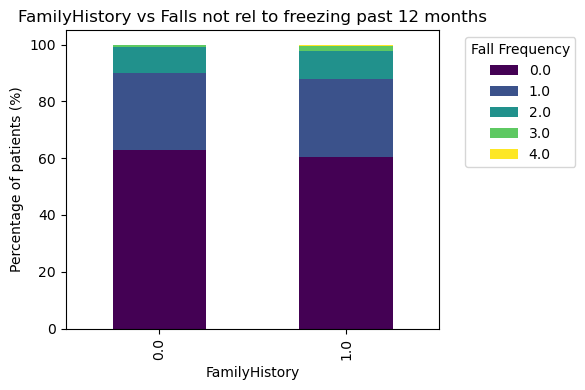

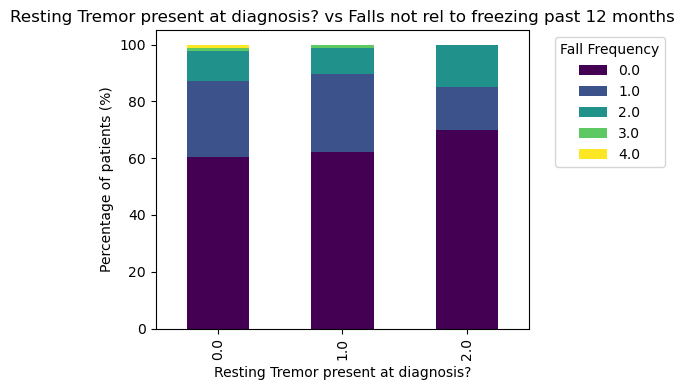

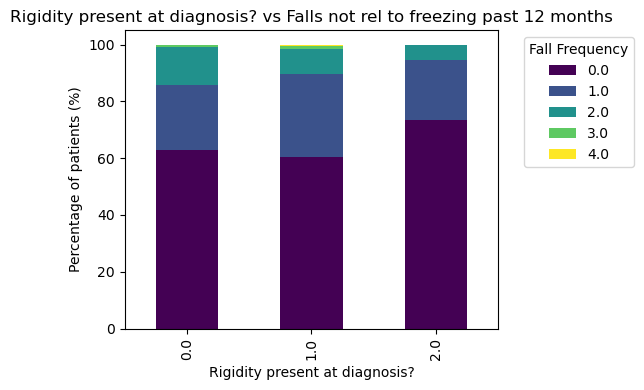

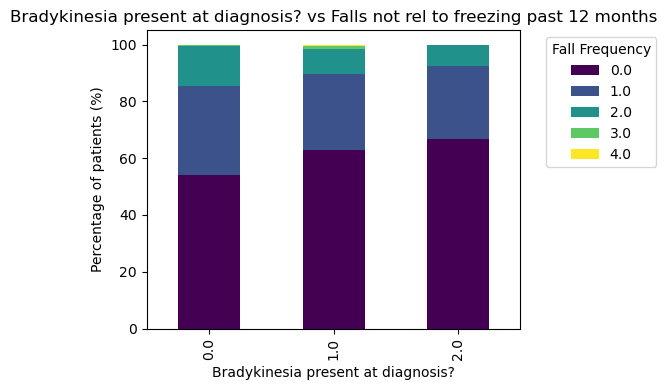

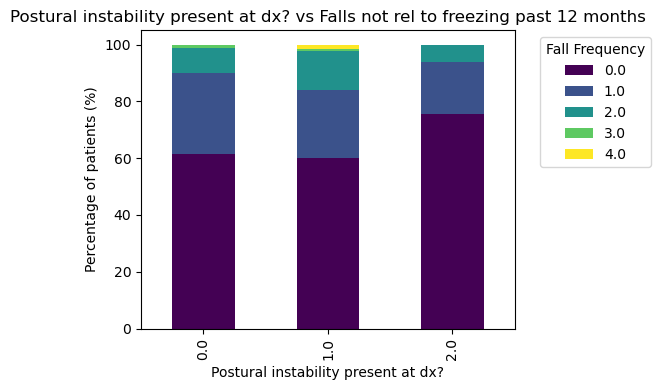

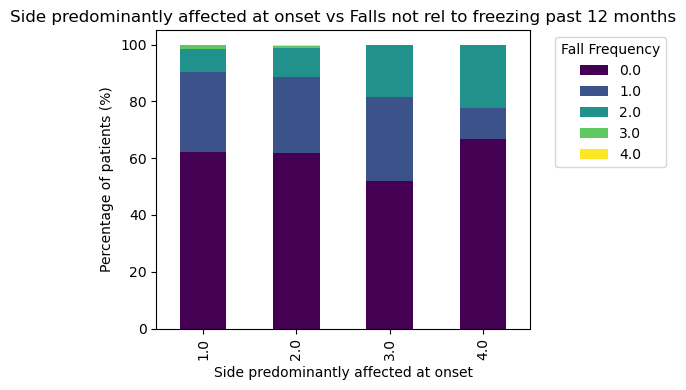

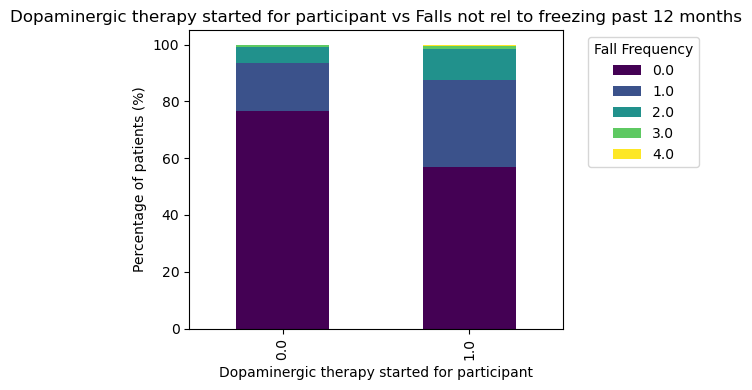

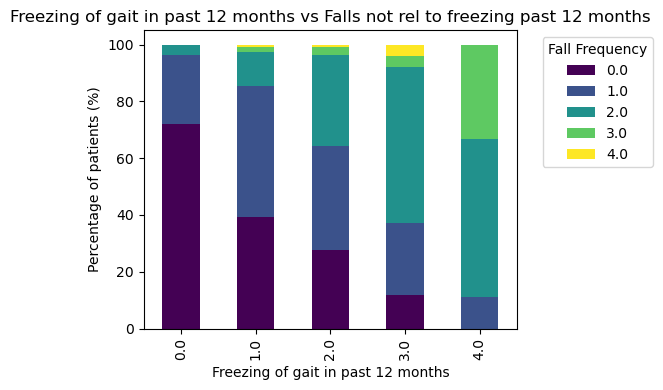

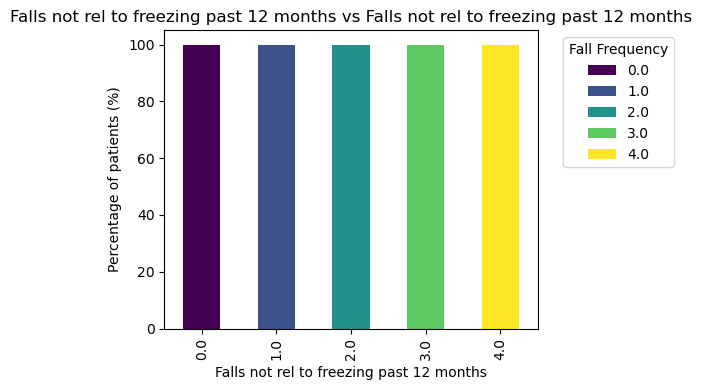

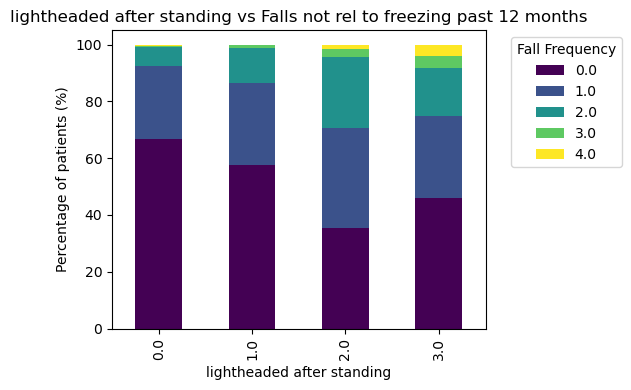

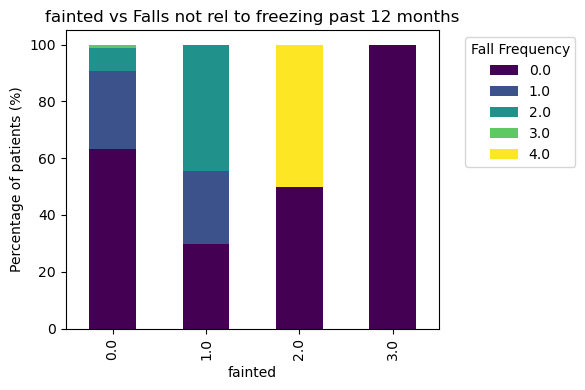

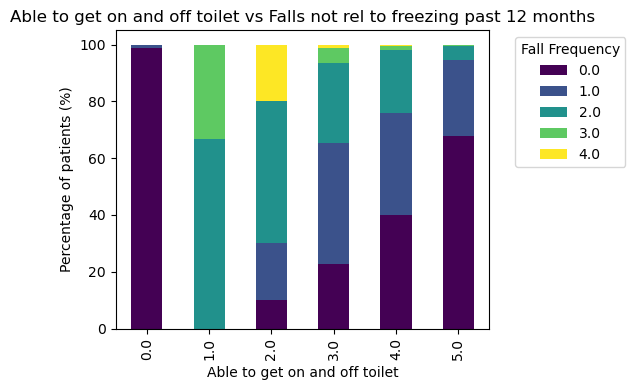

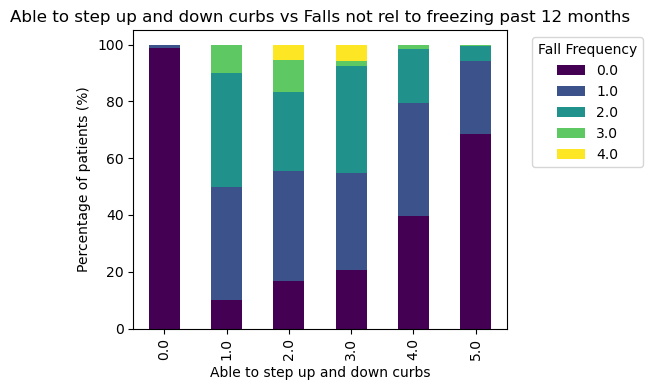

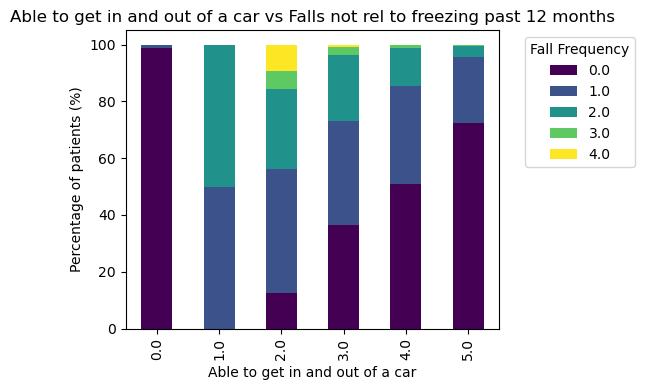

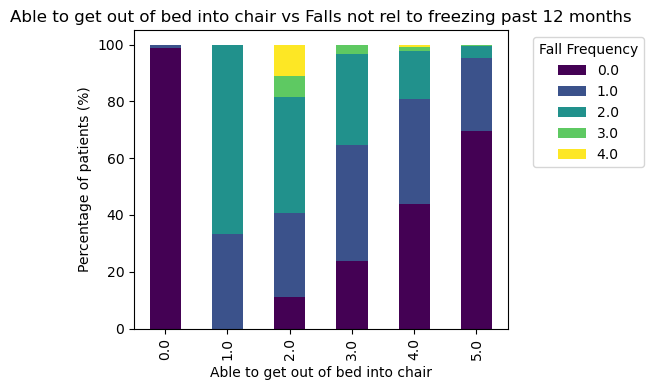

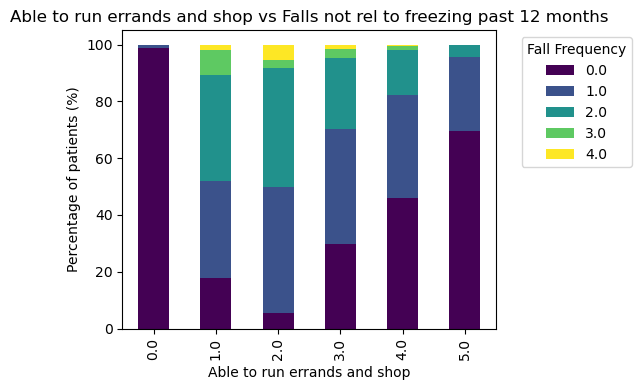

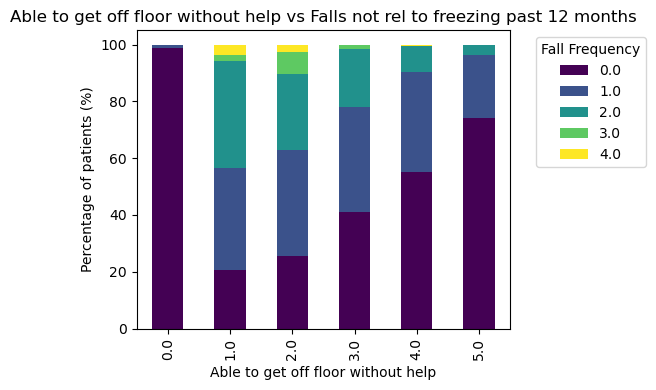

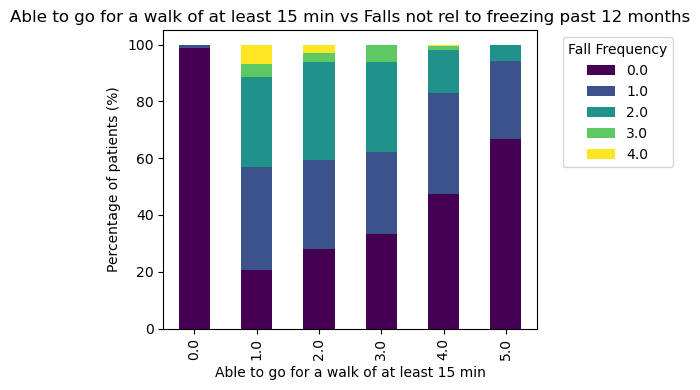

In [185]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_stacked_bar(col):
    ctab = pd.crosstab(data[col], data[target], normalize='index') * 100
    ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='viridis')
    plt.title(f"{col} vs {target}")
    plt.ylabel("Percentage of patients (%)")
    plt.legend(title='Fall Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

for col in cat_cols:  # visualize top 5
    plot_stacked_bar(col)


The proportions of higher fall frequencies look fairly similar across all sides.
No bar shows a strikingly different pattern for the features Rigidity present at diagnosis?	, Bradykinesia present at diagnosis?, FamilyHistory,
Resting Tremor present at diagnosis?, Side predominantly affected at onset


## Model Prediction

In [189]:
#not including 'Fall related consequences' in the training data
cols = ['No_of_years',
       'Postural instability present at dx?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 12 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score','BMI'
]

X = data[cols]
Y = data['Falls not rel to freezing past 12 months']

In [191]:
X.shape

(1173, 17)

In [195]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify=Y)


In [197]:
## Logistic Regression Model

In [220]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

numeric_cols = [
    'MDS-UPDRS PartIV score',
    'No_of_years',
    'Total Depression Score',
    'MoCA Total Score',
    'BMI'
]
odinal_columns=[
    'Postural instability present at dx?',
       'Dopaminergic therapy started for participant',
       'Freezing of gait in past 12 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min',
]
target = 'Falls not rel to freezing past 12 months'

# preprocessing
preprocessor = ColumnTransformer([
    ('numeric', MinMaxScaler(), numeric_cols + odinal_columns)
])

# pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000,
        multi_class='multinomial',
        class_weight='balanced'))
])

pipe.fit(X_train, y_train)
# Evaluate
from sklearn.metrics import classification_report, accuracy_score
y_pred = pipe.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6022727272727273
              precision    recall  f1-score   support

         0.0       0.78      0.75      0.76       218
         1.0       0.48      0.39      0.43        96
         2.0       0.40      0.29      0.34        34
         3.0       0.08      0.67      0.14         3
         4.0       0.00      0.00      0.00         1

    accuracy                           0.60       352
   macro avg       0.35      0.42      0.33       352
weighted avg       0.65      0.60      0.62       352



In [222]:
import numpy as np
import pandas as pd

feature_names = numeric_cols + odinal_columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': pipe.named_steps['model'].coef_[0]
}).sort_values(by='Coefficient', ascending=False)
coef_df


,Feature,Coefficient
15,Able to get off floor without help,1.949663
3,MoCA Total Score,1.023866
4,BMI,0.531630
8,lightheaded after standing,0.229460
14,Able to run errands and shop,0.209765
5,Postural instability present at dx?,0.173912
12,Able to get in and out of a car,0.107768
16,Able to go for a walk of at least 15 min,-0.123186
6,Dopaminergic therapy started for participant,-0.126364
13,Able to get out of bed into chair,-0.605662


## Random Forest Model

Random Forest Accuracy: 0.65625
              precision    recall  f1-score   support

         0.0       0.72      0.91      0.81       218
         1.0       0.38      0.21      0.27        96
         2.0       0.48      0.35      0.41        34
         3.0       0.00      0.00      0.00         3
         4.0       0.00      0.00      0.00         1

    accuracy                           0.66       352
   macro avg       0.32      0.29      0.30       352
weighted avg       0.60      0.66      0.61       352



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


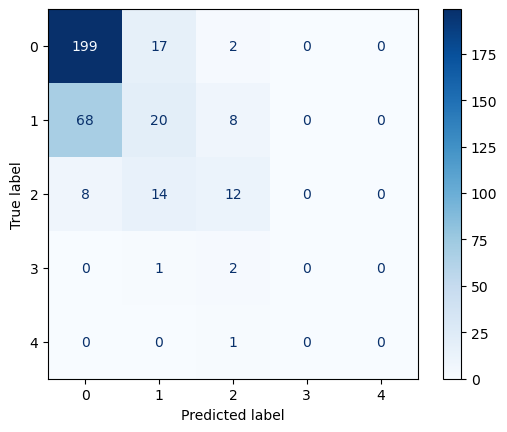

In [204]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(cmap='Blues')


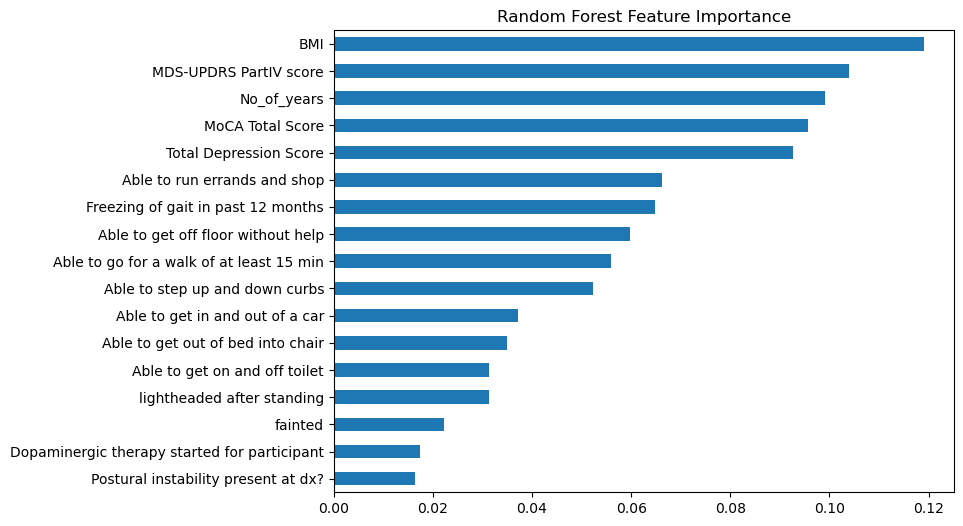

In [206]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(8,6))
plt.title('Random Forest Feature Importance')
plt.show()


In [208]:
## XG Boost

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:24:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.65625
              precision    recall  f1-score   support

         0.0       0.72      0.87      0.79       218
         1.0       0.44      0.29      0.35        96
         2.0       0.54      0.41      0.47        34
         3.0       0.00      0.00      0.00         3
         4.0       0.00      0.00      0.00         1

    accuracy                           0.66       352
   macro avg       0.34      0.31      0.32       352
weighted avg       0.62      0.66      0.63       352



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


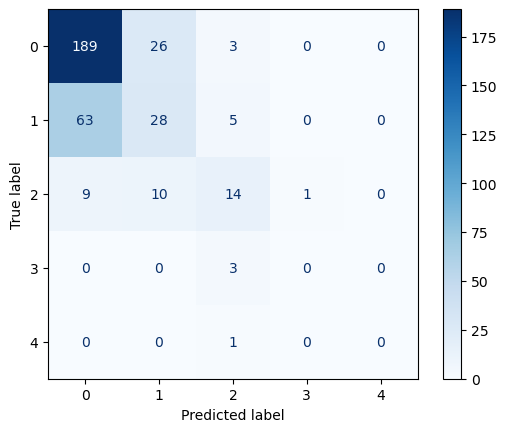

In [228]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(Y.unique()),
    eval_metric='mlogloss',
    learning_rate=0.1,
    n_estimators=400,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb)).plot(cmap='Blues')


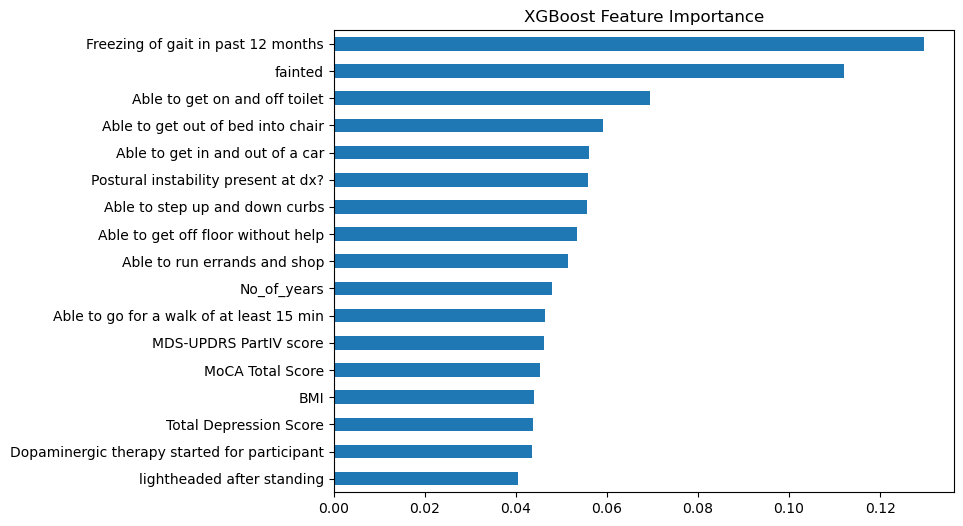

In [232]:
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance')
plt.show()


In [214]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

# Parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2,3],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.92      0.82       218
         1.0       0.45      0.25      0.32        96
         2.0       0.42      0.32      0.37        34
         3.0       0.00      0.00      0.00         3
         4.0       0.00      0.00      0.00         1

    accuracy                           0.67       352
   macro avg       0.32      0.30      0.30       352
weighted avg       0.62      0.67      0.63       352



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [226]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True))
])

svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6505681818181818
              precision    recall  f1-score   support

         0.0       0.79      0.79      0.79       218
         1.0       0.47      0.36      0.41        96
         2.0       0.38      0.62      0.47        34
         3.0       0.00      0.00      0.00         3
         4.0       1.00      1.00      1.00         1

    accuracy                           0.65       352
   macro avg       0.53      0.55      0.53       352
weighted avg       0.66      0.65      0.65       352

